# EDA — IMF & World Bank macro features, Ukraine

Macro overlays for the weekly GDELT conflict panel, fetched by
`src/data/fetch_imf_worldbank.py` and as-of joined onto ISO weeks.

**Sources**
- **World Bank WDI** — annual GDP, inflation, unemployment, military spending, population, debt, reserves, trade, remittances
- **IMF SDMX 3.0** — monthly CPI, UAH/USD, international reserves, REER; annual WEO (growth, inflation, unemployment, debt, current account)
- **World Bank Pink Sheet** — monthly Brent, European gas, wheat, sunflower oil, energy/food indices

**Leakage rule.** Monthly series become usable 45 days after month-end; annual series 180 days after year-end. Weekly row `t` only sees releases whose `available_date` is on or before Sunday of that week.

```bash
python -m src.data.fetch_imf_worldbank
```

**Contents**
1. Load data
2. Series catalog & coverage
3. Monthly IMF (CPI, FX, reserves, REER)
4. World Bank commodities
5. Annual WDI / WEO
6. As-of join onto the weekly conflict panel
7. Correlations with `conflict_count`
8. Pre / post Feb-2022 regimes
9. Publication-lag illustration
10. Takeaways


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils import load_config, repo_path
from src.data.fetch_imf_worldbank import (
    MACRO_MODEL_FEATURES,
    catalog_from_long,
    fetch_and_build,
)

plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

cfg = load_config()
cfg["country"], cfg["macro"], cfg["data"]["start_date"], cfg["data"]["end_date"]


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


({'name': 'Ukraine', 'gdelt_code': 'UP'},
 {'monthly_lag_days': 45, 'annual_lag_days': 180},
 '2022-01-01',
 '2026-09-07')

## 1. Load data

Rebuild the IMF / World Bank caches if they are missing, then load:
- `long` — native-frequency series (one row per series × period)
- `weekly_macro` — leakage-safe as-of panel (one row per GDELT week)
- `conflict` — GDELT weekly `conflict_count` for overlays


In [2]:
long_df, weekly_macro = fetch_and_build(cfg, force=False)
catalog = catalog_from_long(long_df)

conflict_path = repo_path(cfg["data"]["weekly_panel_path"])
conflict = pd.read_parquet(conflict_path)[["week_start", "conflict_count", "days_covered"]].copy()
conflict["week_start"] = pd.to_datetime(conflict["week_start"])
weekly_macro = weekly_macro.copy()
weekly_macro["week_start"] = pd.to_datetime(weekly_macro["week_start"])

panel = conflict.merge(weekly_macro, on="week_start", how="left")

print(f"long:          {len(long_df):,} rows, {long_df['series'].nunique()} series")
print(f"weekly_macro:  {len(weekly_macro)} weeks × {weekly_macro.shape[1]} cols")
print(f"conflict join: {len(panel)} weeks, {panel['week_start'].min().date()} .. {panel['week_start'].max().date()}")
print(f"model features present: {sum(c in panel.columns for c in MACRO_MODEL_FEATURES)} / {len(MACRO_MODEL_FEATURES)}")
catalog.sort_values(["freq", "series"]).reset_index(drop=True)


[fetch_imf_worldbank] Using cached /home/romanrussia/Code_git/GDETL/data/processed/macro_series_long.parquet and /home/romanrussia/Code_git/GDETL/data/processed/macro_weekly_panel.parquet
long:          4,844 rows, 42 series
weekly_macro:  245 weeks × 43 cols
conflict join: 245 weeks, 2021-12-27 .. 2026-08-31
model features present: 20 / 20


,series,label,source,freq,n_obs,start,end,latest_value,model_feature
0,imf_weo_ca_gdp,WEO current account balance (% of GDP),IMF WEO,A,40,1992,2031,-7.371187e+00,False
1,imf_weo_debt_gdp,WEO general government gross debt (% of GDP),IMF WEO,A,35,1997,2031,1.196087e+02,True
2,imf_weo_gdp_growth,WEO real GDP growth (annual %),IMF WEO,A,40,1992,2031,3.600000e+00,True
3,imf_weo_gov_exp_gdp,WEO general government expenditure (% of GDP),IMF WEO,A,37,1995,2031,4.401921e+01,False
4,imf_weo_inflation,"WEO CPI inflation, period average (annual %)",IMF WEO,A,40,1992,2031,4.998175e+00,True
5,imf_weo_unemployment,WEO unemployment rate (%),IMF WEO,A,37,1995,2031,9.290307e+00,False
6,wb_current_account_gdp,Current account balance (% of GDP),WDI BN.CAB.XOKA.GD.ZS,A,7,2018,2024,-7.960328e+00,False
7,wb_exports_gdp,Exports of goods and services (% of GDP),WDI NE.EXP.GNFS.ZS,A,8,2018,2025,2.533353e+01,False
8,wb_external_debt_usd,"External debt stocks, total (DOD, current US$)",WDI DT.DOD.DECT.CD,A,7,2018,2024,1.934925e+11,False
9,wb_gdp_current_usd,GDP (current US$),WDI NY.GDP.MKTP.CD,A,8,2018,2025,2.142333e+11,False


## 2. Series catalog & coverage

Native-frequency span, latest value, and whether the series is in the **model** feature list (a curated subset — the weekly panel keeps everything for EDA).


In [3]:
display_cols = ["series", "label", "source", "freq", "n_obs", "start", "end", "latest_value", "model_feature"]
cat_show = catalog[display_cols].copy()
cat_show["latest_value"] = cat_show["latest_value"].map(lambda x: f"{x:,.4g}")
print("Monthly series:", int((catalog.freq == "M").sum()), "| Annual:", int((catalog.freq == "A").sum()))
cat_show


Monthly series: 19 | Annual: 23


,series,label,source,freq,n_obs,start,end,latest_value,model_feature
0,imf_cpi_index,CPI all-items index (monthly),IMF CPI,M,259,2005-M01,2026-M07,539.3,True
1,imf_cpi_mom,CPI all-items index (monthly) — month-on-month %,IMF CPI,M,258,2005-M02,2026-M07,0.002976,True
2,imf_cpi_yoy,CPI all-items index (monthly) — year-on-year %,IMF CPI,M,247,2006-M01,2026-M07,0.07731,True
3,imf_fx_mom,"UAH per USD, period average (monthly) — month-...",IMF ER,M,404,1993-M01,2026-M08,-0.0003333,True
4,imf_fx_uah_usd,"UAH per USD, period average (monthly)",IMF ER,M,405,1992-M12,2026-M08,44.69,True
5,imf_fx_yoy,"UAH per USD, period average (monthly) — year-o...",IMF ER,M,393,1993-M12,2026-M08,0.07832,False
6,imf_reer,"Real effective exchange rate, CPI-based (2010=...",IMF EER,M,405,1992-M12,2026-M08,84.37,True
7,imf_reserves_mom,"Total reserves, gold at market value (USD, mon...",IMF IL,M,403,1993-M01,2026-M07,-0.002067,True
8,imf_reserves_usd,"Total reserves, gold at market value (USD, mon...",IMF IL,M,404,1992-M12,2026-M07,5.115e+10,True
9,imf_reserves_yoy,"Total reserves, gold at market value (USD, mon...",IMF IL,M,392,1993-M12,2026-M07,0.1895,False


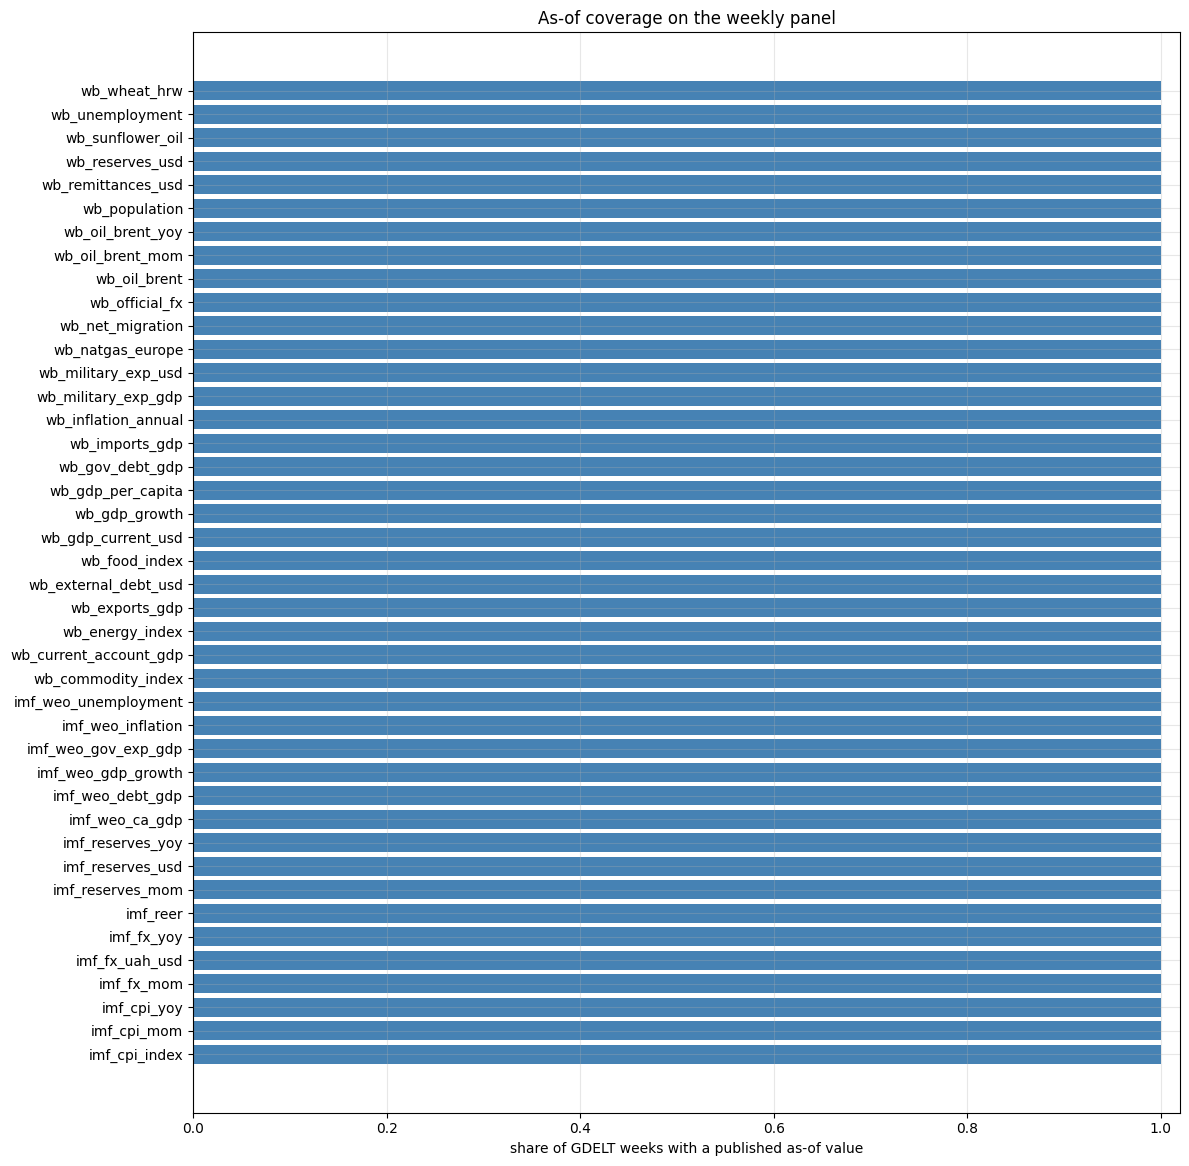

,share_non_null,n_non_null
wb_natgas_europe,1.0,245
wb_net_migration,1.0,245
wb_official_fx,1.0,245
wb_oil_brent,1.0,245
wb_oil_brent_mom,1.0,245
wb_oil_brent_yoy,1.0,245
wb_population,1.0,245
wb_remittances_usd,1.0,245
wb_reserves_usd,1.0,245
wb_sunflower_oil,1.0,245


In [4]:
# Coverage heatmap: share of weekly rows with a non-null as-of value
macro_cols = [c for c in weekly_macro.columns if c != "week_start"]
cov = (
    panel[macro_cols]
    .notna()
    .mean()
    .sort_values()
    .to_frame("share_non_null")
    .assign(n_non_null=lambda d: (d["share_non_null"] * len(panel)).round().astype(int))
)
fig, ax = plt.subplots(figsize=(12, max(4, 0.28 * len(cov))))
ax.barh(cov.index, cov["share_non_null"], color="steelblue")
ax.set_xlim(0, 1.02)
ax.set_xlabel("share of GDELT weeks with a published as-of value")
ax.set_title("As-of coverage on the weekly panel")
fig.tight_layout()
plt.show()
cov.tail(12)


## 3. Monthly IMF: prices, FX, reserves, REER

These are the high-frequency macro series — the ones that can actually move inside a 1–4 week forecast horizon. CPI YoY is derived from the monthly index (`pct_change(12)` on the native series, then as-of joined).


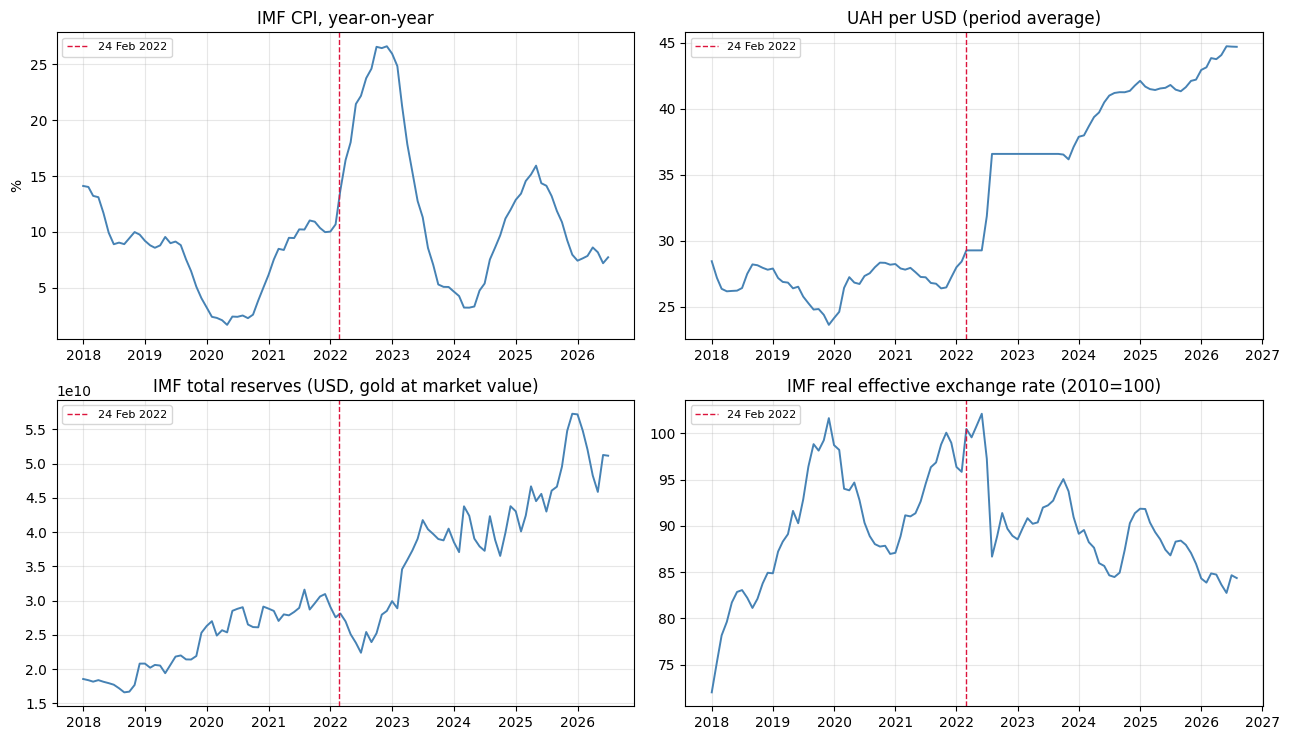

In [5]:
def series_ts(name: str) -> pd.DataFrame:
    s = long_df[long_df["series"] == name].sort_values("period_start").copy()
    s = s[s["period_start"] >= "2018-01-01"]
    return s

invasion = pd.Timestamp("2022-02-24")

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5), sharex=False)
plots = [
    ("imf_cpi_yoy", "IMF CPI, year-on-year", axes[0, 0], True),
    ("imf_fx_uah_usd", "UAH per USD (period average)", axes[0, 1], False),
    ("imf_reserves_usd", "IMF total reserves (USD, gold at market value)", axes[1, 0], False),
    ("imf_reer", "IMF real effective exchange rate (2010=100)", axes[1, 1], False),
]
for name, title, ax, as_pct in plots:
    s = series_ts(name)
    y = s["value"] * 100 if as_pct else s["value"]
    ax.plot(s["period_start"], y, color="steelblue", lw=1.4)
    ax.axvline(invasion, color="crimson", ls="--", lw=1, label="24 Feb 2022")
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    if as_pct:
        ax.set_ylabel("%")
fig.tight_layout()
plt.show()


CPI YoY spiked with the invasion and the 2022 devaluation; the hryvnia then sat on a wartime peg (~36.6) until a mid-2023 adjustment toward ~41, with reserves recovering after the 2022 drawdown. REER is the inflation-adjusted competitiveness summary of those FX + CPI moves.


## 4. World Bank Pink Sheet commodities

Ukraine is a top wheat and sunflower-oil exporter; European gas and Brent are the external energy shock. These are *global* prices (not Ukraine-specific), used as external regressors.


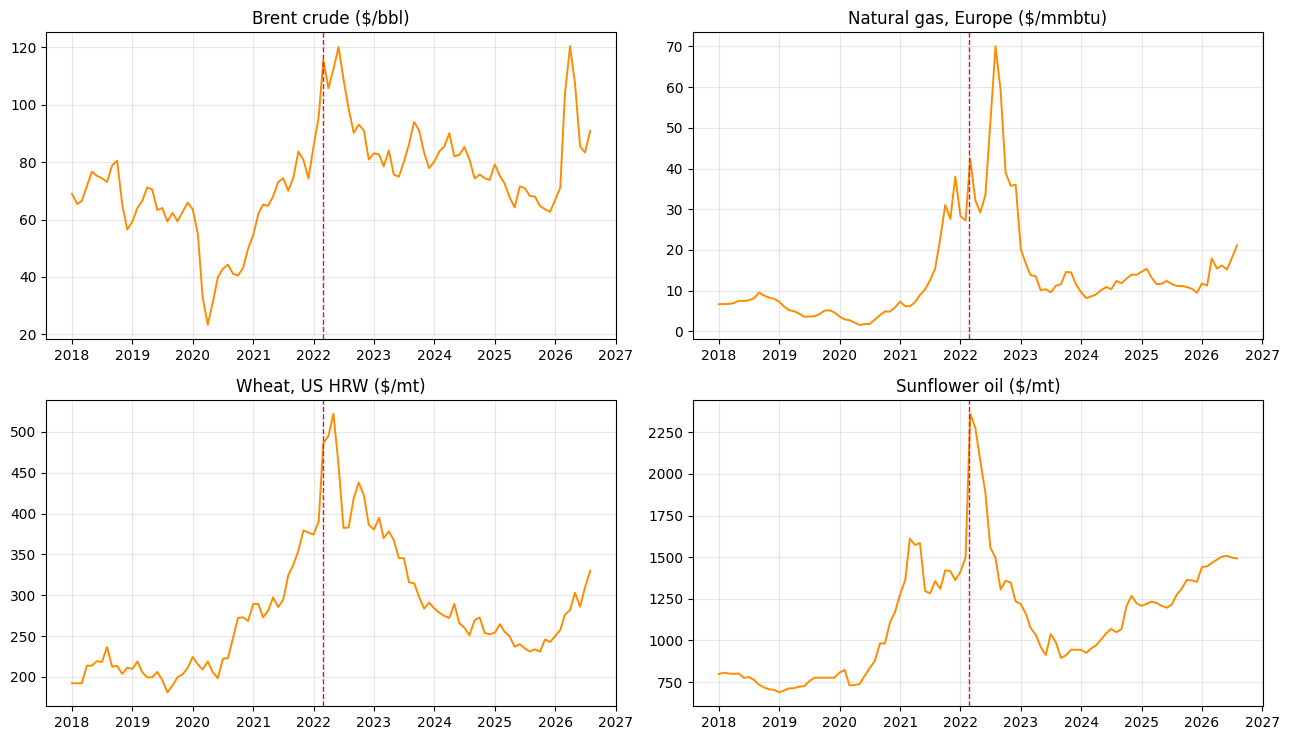

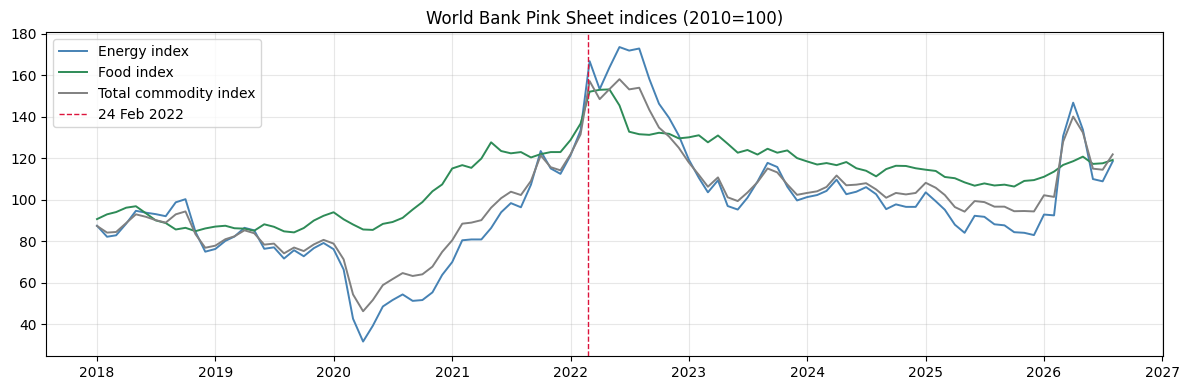

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
commodity_plots = [
    ("wb_oil_brent", "Brent crude ($/bbl)", axes[0, 0]),
    ("wb_natgas_europe", "Natural gas, Europe ($/mmbtu)", axes[0, 1]),
    ("wb_wheat_hrw", "Wheat, US HRW ($/mt)", axes[1, 0]),
    ("wb_sunflower_oil", "Sunflower oil ($/mt)", axes[1, 1]),
]
for name, title, ax in commodity_plots:
    s = series_ts(name)
    ax.plot(s["period_start"], s["value"], color="darkorange", lw=1.4)
    ax.axvline(invasion, color="crimson", ls="--", lw=1)
    ax.set_title(title)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for name, label, color in [
    ("wb_energy_index", "Energy index", "steelblue"),
    ("wb_food_index", "Food index", "seagreen"),
    ("wb_commodity_index", "Total commodity index", "grey"),
]:
    s = series_ts(name)
    ax.plot(s["period_start"], s["value"], label=label, color=color, lw=1.4)
ax.axvline(invasion, color="crimson", ls="--", lw=1, label="24 Feb 2022")
ax.set_title("World Bank Pink Sheet indices (2010=100)")
ax.legend()
fig.tight_layout()
plt.show()


## 5. Annual WDI / WEO

Slow-moving structural series. They barely change week-to-week, but the 2022 level shift (GDP collapse, military spending, current-account swing) is a useful **regime** feature for tree models. WEO years ≥ 2026 are the latest-vintage *projections* — the weekly as-of join does **not** use them until 180 days after that year ends.


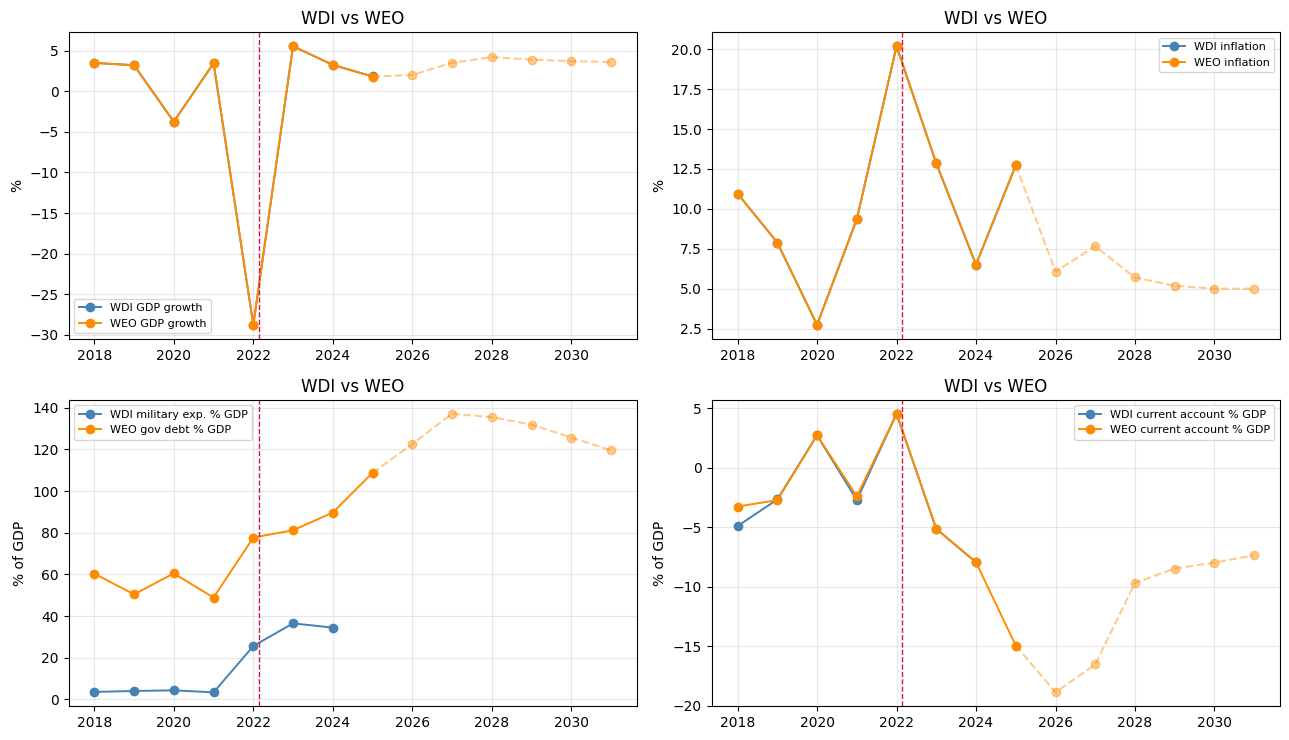

In [7]:
annual_keep = [
    "wb_gdp_growth", "imf_weo_gdp_growth",
    "wb_inflation_annual", "imf_weo_inflation",
    "wb_military_exp_gdp", "imf_weo_debt_gdp",
    "wb_current_account_gdp", "imf_weo_ca_gdp",
    "wb_population", "wb_net_migration",
]
annual = long_df[long_df["series"].isin(annual_keep)].copy()
annual = annual[annual["period_start"].dt.year.between(2018, 2031)]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
pairs = [
    (("wb_gdp_growth", "WDI GDP growth"), ("imf_weo_gdp_growth", "WEO GDP growth"), axes[0, 0], "%"),
    (("wb_inflation_annual", "WDI inflation"), ("imf_weo_inflation", "WEO inflation"), axes[0, 1], "%"),
    (("wb_military_exp_gdp", "WDI military exp. % GDP"), ("imf_weo_debt_gdp", "WEO gov debt % GDP"), axes[1, 0], "% of GDP"),
    (("wb_current_account_gdp", "WDI current account % GDP"), ("imf_weo_ca_gdp", "WEO current account % GDP"), axes[1, 1], "% of GDP"),
]
for (a, la), (b, lb), ax, ylab in pairs:
    for name, label, color in ((a, la, "steelblue"), (b, lb, "darkorange")):
        s = annual[annual["series"] == name].sort_values("period_start")
        hist = s[s["period_start"].dt.year <= 2025]
        fut = s[s["period_start"].dt.year >= 2025]
        ax.plot(hist["period_start"], hist["value"], "o-", color=color, lw=1.4, label=label)
        if name.startswith("imf_weo") and not fut.empty:
            ax.plot(fut["period_start"], fut["value"], "o--", color=color, alpha=0.45)
    ax.axvline(invasion, color="crimson", ls="--", lw=1)
    ax.set_title(f"{la.split()[0]} vs {lb.split()[0]}")
    ax.set_ylabel(ylab)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


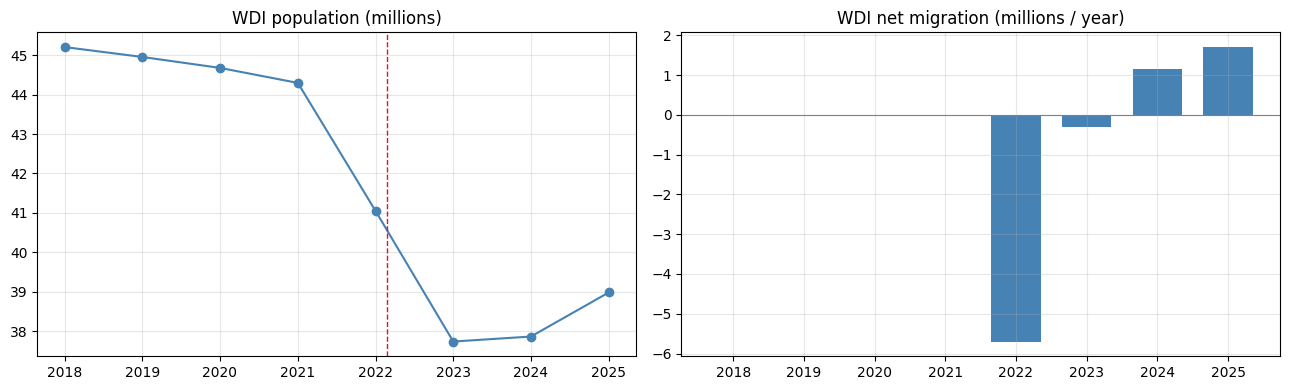

WDI / WEO 2021–2025 snapshot


series,imf_weo_ca_gdp,imf_weo_debt_gdp,imf_weo_gdp_growth,imf_weo_inflation,wb_current_account_gdp,wb_gdp_growth,wb_inflation_annual,wb_military_exp_gdp,wb_net_migration,wb_population
year,,,,,,,,,,
2021,-2.41,48.92,3.45,9.36,-2.73,3.45,9.36,3.43,-1129.0,44298640.0
2022,4.52,77.72,-28.76,20.18,4.52,-28.76,20.18,25.64,-5699445.0,41048766.0
2023,-5.15,81.21,5.53,12.85,-5.15,5.53,12.85,36.53,-299961.0,37732836.0
2024,-7.96,89.68,3.25,6.50,-7.96,3.25,6.50,34.48,1146012.0,37860221.0
2025,-14.96,108.75,1.80,12.73,NaN,1.82,12.73,NaN,1702358.0,38980376.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pop = annual[annual["series"] == "wb_population"].sort_values("period_start")
mig = annual[annual["series"] == "wb_net_migration"].sort_values("period_start")
axes[0].plot(pop["period_start"], pop["value"] / 1e6, "o-", color="steelblue")
axes[0].axvline(invasion, color="crimson", ls="--", lw=1)
axes[0].set_title("WDI population (millions)")
axes[1].bar(mig["period_start"].dt.year, mig["value"] / 1e6, color="steelblue", width=0.7)
axes[1].axhline(0, color="grey", lw=0.8)
axes[1].set_title("WDI net migration (millions / year)")
fig.tight_layout()
plt.show()

print("WDI / WEO 2021–2025 snapshot")
snap = (
    annual[annual["period_start"].dt.year.between(2021, 2025)]
    .assign(year=lambda d: d["period_start"].dt.year)
    .pivot_table(index="year", columns="series", values="value")
)
snap.round(2)


## 6. As-of join onto the weekly conflict panel

`weekly_macro` is what the models see: each Monday week gets the latest *already-published* value. Overlay a few monthly series against `conflict_count` (dual axis).


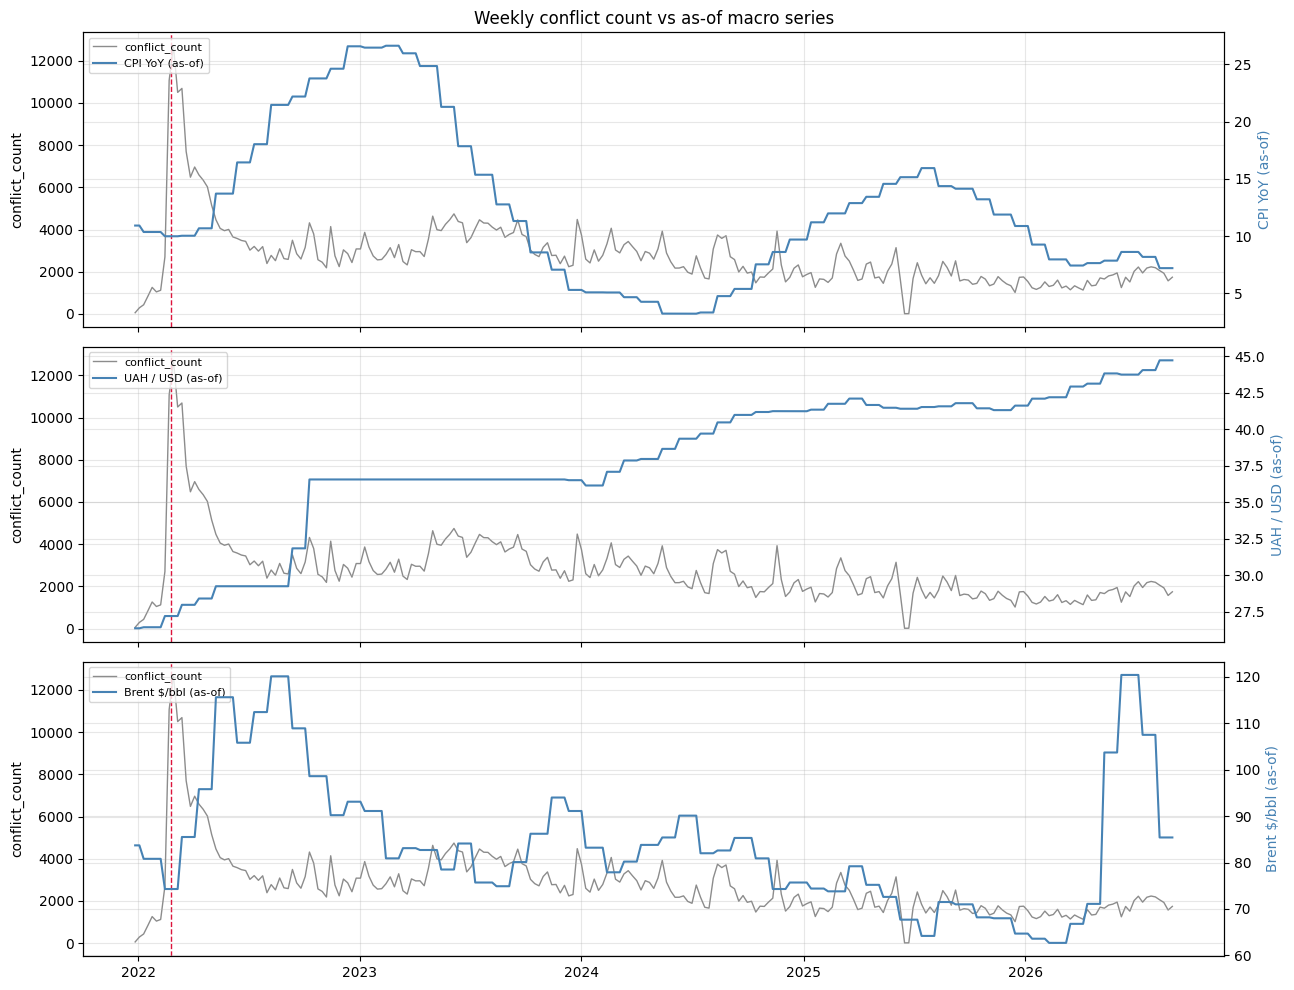

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
overlays = [
    ("imf_cpi_yoy", "CPI YoY (as-of)", True),
    ("imf_fx_uah_usd", "UAH / USD (as-of)", False),
    ("wb_oil_brent", "Brent $/bbl (as-of)", False),
]
for ax, (col, label, as_pct) in zip(axes, overlays):
    ax.plot(panel["week_start"], panel["conflict_count"], color="0.55", lw=1, label="conflict_count")
    ax.set_ylabel("conflict_count")
    ax2 = ax.twinx()
    y = panel[col] * 100 if as_pct else panel[col]
    ax2.plot(panel["week_start"], y, color="steelblue", lw=1.5, label=label)
    ax2.set_ylabel(label, color="steelblue")
    ax.axvline(invasion, color="crimson", ls="--", lw=1)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
axes[0].set_title("Weekly conflict count vs as-of macro series")
fig.tight_layout()
plt.show()


## 7. Correlations with `conflict_count`

Pearson correlation of each as-of macro column with weekly conflict counts, full sample and post-invasion only. Annual series that are constant within a year will look strong if they simply mark the war regime — interpret those as **level-shift / regime** correlates, not as week-ahead predictors.


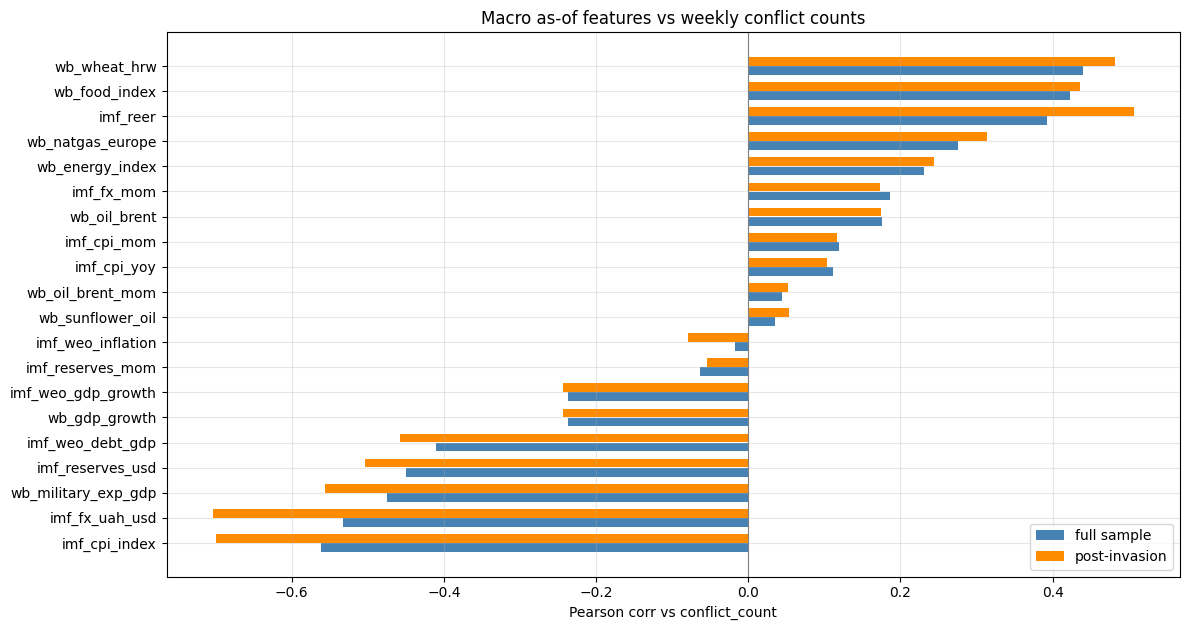

,full_sample,post_invasion
imf_cpi_index,-0.561,-0.700
imf_fx_uah_usd,-0.533,-0.704
wb_military_exp_gdp,-0.474,-0.556
imf_reserves_usd,-0.450,-0.504
imf_weo_debt_gdp,-0.410,-0.458
wb_gdp_growth,-0.237,-0.243
imf_weo_gdp_growth,-0.237,-0.243
imf_reserves_mom,-0.064,-0.054
imf_weo_inflation,-0.017,-0.079
wb_sunflower_oil,0.035,0.053


In [10]:
INVASION_WEEK = pd.Timestamp("2022-02-21")  # ISO week containing 24 Feb
macro_cols = [c for c in MACRO_MODEL_FEATURES if c in panel.columns]


def corr_block(df, cols):
    out = {}
    y = df["conflict_count"]
    for c in cols:
        pair = df[[c]].join(y)
        out[c] = pair[c].corr(pair["conflict_count"])
    return pd.Series(out)


full = corr_block(panel, macro_cols)
post = corr_block(panel[panel["week_start"] >= INVASION_WEEK], macro_cols)
corr_tbl = pd.DataFrame({"full_sample": full, "post_invasion": post}).sort_values("full_sample")

fig, ax = plt.subplots(figsize=(12, max(4.5, 0.32 * len(corr_tbl))))
ypos = np.arange(len(corr_tbl))
ax.barh(ypos - 0.18, corr_tbl["full_sample"], height=0.35, color="steelblue", label="full sample")
ax.barh(ypos + 0.18, corr_tbl["post_invasion"], height=0.35, color="darkorange", label="post-invasion")
ax.set_yticks(ypos, corr_tbl.index)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Pearson corr vs conflict_count")
ax.set_title("Macro as-of features vs weekly conflict counts")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()
corr_tbl.round(3)


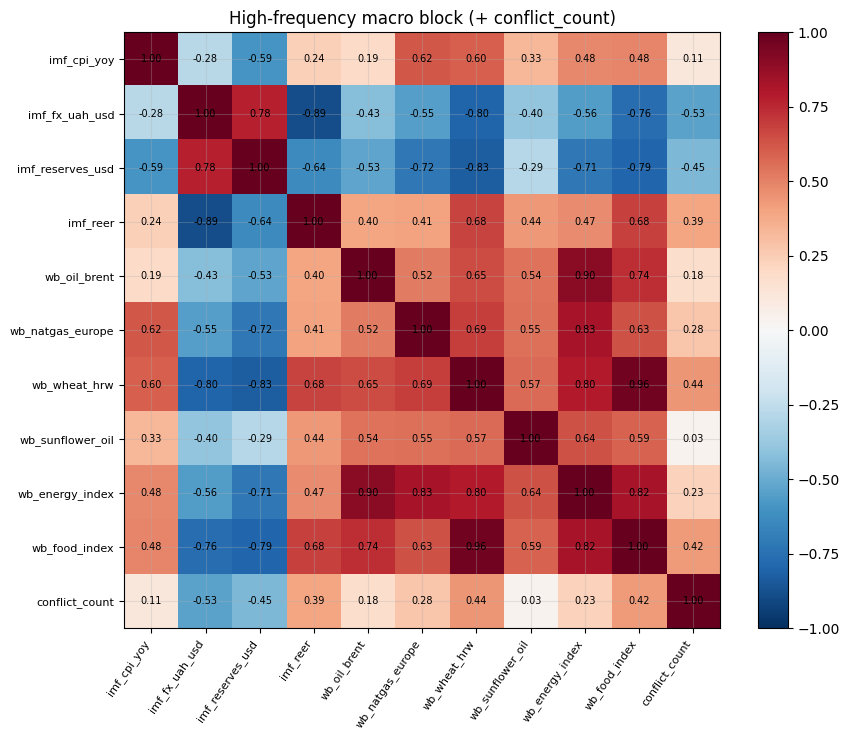

In [11]:
# Cross-correlation among the high-frequency block (avoid the annual constants)
hf = [c for c in [
    "imf_cpi_yoy", "imf_fx_uah_usd", "imf_reserves_usd", "imf_reer",
    "wb_oil_brent", "wb_natgas_europe", "wb_wheat_hrw", "wb_sunflower_oil",
    "wb_energy_index", "wb_food_index", "conflict_count",
] if c in panel.columns]
corr = panel[hf].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(hf)), hf, rotation=55, ha="right", fontsize=8)
ax.set_yticks(range(len(hf)), hf, fontsize=8)
for i in range(len(hf)):
    for j in range(len(hf)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("High-frequency macro block (+ conflict_count)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
plt.show()


## 8. Pre / post Feb-2022 regimes

Compare the distribution of monthly series before vs after the invasion. This is why a single global correlation can be misleading: the war is a permanent level shift in both conflict *and* the macro environment.


/tmp/ipykernel_121121/946819921.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["pre", "post"], showfliers=False)
/tmp/ipykernel_121121/946819921.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["pre", "post"], showfliers=False)
/tmp/ipykernel_121121/946819921.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["pre", "post"], showfliers=False)
/tmp/ipykernel_121121/946819921.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dr

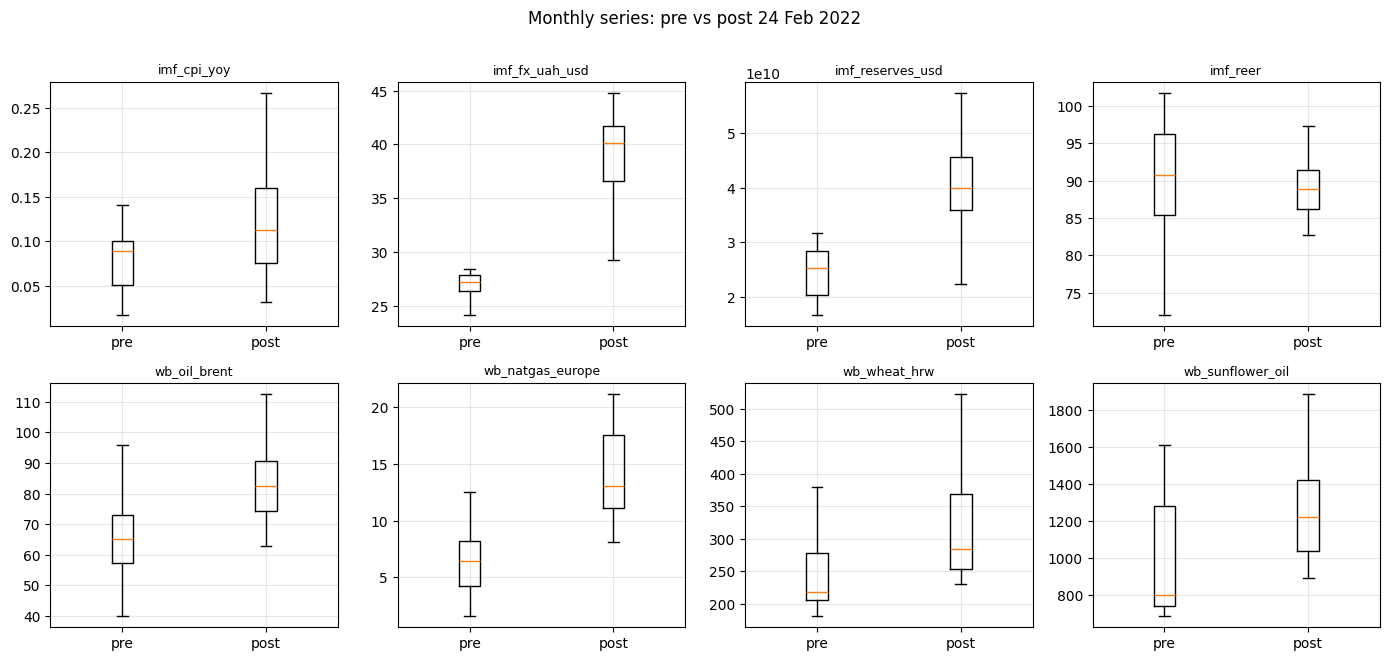

In [12]:
native_m = long_df[long_df["series"].isin([
    "imf_cpi_yoy", "imf_fx_uah_usd", "imf_reserves_usd", "imf_reer",
    "wb_oil_brent", "wb_natgas_europe", "wb_wheat_hrw", "wb_sunflower_oil",
])].copy()
native_m = native_m[native_m["period_start"] >= "2018-01-01"]
native_m["regime"] = np.where(native_m["period_start"] >= invasion, "post-invasion", "pre-invasion")

fig, axes = plt.subplots(2, 4, figsize=(14, 6.5))
for ax, name in zip(axes.ravel(), [
    "imf_cpi_yoy", "imf_fx_uah_usd", "imf_reserves_usd", "imf_reer",
    "wb_oil_brent", "wb_natgas_europe", "wb_wheat_hrw", "wb_sunflower_oil",
]):
    sub = native_m[native_m["series"] == name]
    data = [sub.loc[sub["regime"] == r, "value"].dropna() for r in ("pre-invasion", "post-invasion")]
    ax.boxplot(data, labels=["pre", "post"], showfliers=False)
    ax.set_title(name, fontsize=9)
fig.suptitle("Monthly series: pre vs post 24 Feb 2022", y=1.01)
fig.tight_layout()
plt.show()


## 9. Publication-lag illustration

For one monthly series (CPI), show the native month vs the value a weekly origin is actually allowed to see. The as-of line lags the raw print by ~1–2 months — that is intentional.


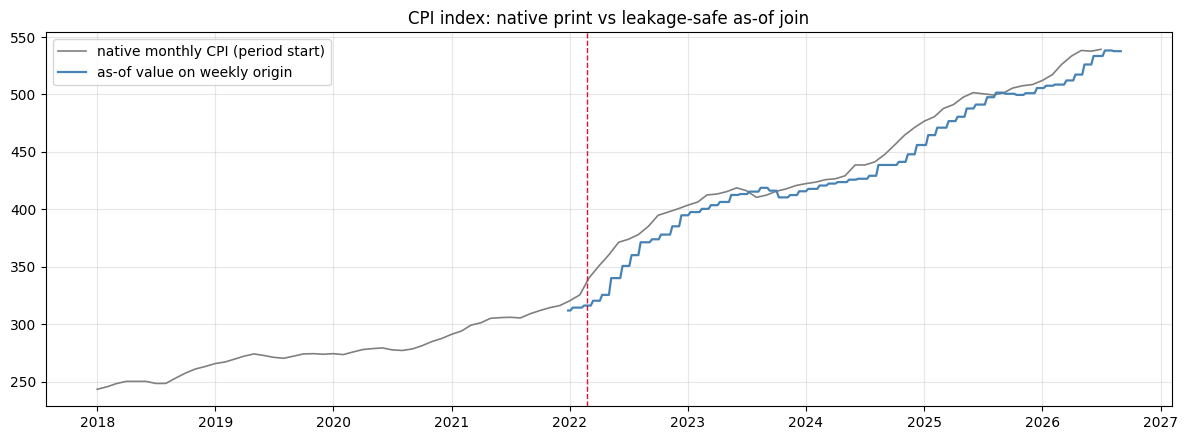

last GDELT week:     2026-08-31
latest native CPI:   2026-07-01
as-of CPI on that week matches native period: 2026-06-01
monthly_lag_days=45, annual_lag_days=180


In [13]:
cpi_native = series_ts("imf_cpi_index")
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(cpi_native["period_start"], cpi_native["value"], color="0.5", lw=1.2, label="native monthly CPI (period start)")
ax.plot(panel["week_start"], panel["imf_cpi_index"], color="steelblue", lw=1.6, label="as-of value on weekly origin")
ax.axvline(invasion, color="crimson", ls="--", lw=1)
ax.set_title("CPI index: native print vs leakage-safe as-of join")
ax.legend()
fig.tight_layout()
plt.show()

# How stale is the as-of CPI on the last week?
last_week = panel["week_start"].max()
native_last = cpi_native["period_start"].max()
asof_last = panel.loc[panel["week_start"] == last_week, "imf_cpi_index"].iloc[0]
native_match = cpi_native.loc[cpi_native["value"] == asof_last, "period_start"]
print(f"last GDELT week:     {last_week.date()}")
print(f"latest native CPI:   {native_last.date()}")
print(f"as-of CPI on that week matches native period: {native_match.min().date() if len(native_match) else 'n/a'}")
print(f"monthly_lag_days={cfg['macro']['monthly_lag_days']}, annual_lag_days={cfg['macro']['annual_lag_days']}")


## 10. Takeaways

- **42 series** were pulled (WDI annual, IMF monthly + WEO, Pink Sheet commodities) and as-of joined onto all **245** GDELT weeks.
- **Use the monthly block for forecasting.** CPI YoY, UAH/USD, reserves, REER, Brent, wheat, sunflower oil, and European gas actually move inside a 1–4 week horizon. Annual WDI/WEO are nearly stepwise and mainly encode the 2022 regime (GDP −29%, military spending ~34% of GDP, population/migration break).
- **2022 is a joint structural break.** Conflict counts, CPI, the hryvnia, reserves, and food/energy prices all jump together. A full-sample correlation with `conflict_count` will look large for anything that stepped up in Feb-2022; the **post-invasion** column is the fairer read for week-ahead skill.
- **WEO vs WDI.** They agree on the 2022 collapse / 2023 rebound. WEO extends with projections through 2031 — those future years are in the long table for EDA but are **not** visible to weekly origins under the 180-day year-end lag. WEO is a single latest vintage (later revisions of 2022–2024 are used throughout), which is a documented limitation vs a real-time vintage archive.
- **Coverage holes.** WDI unemployment stops in 2021; central-government debt in 2020. Prefer IMF WEO unemployment / debt for the war years. Military expenditure is WDI through 2024 only.
- Model feature list (`MACRO_MODEL_FEATURES`) is the 20-column curated subset; the rest stay on `macro_weekly_panel` for diagnostics.

Weekly as-of panel: `data/processed/macro_weekly_panel.parquet`  
Long series: `data/processed/macro_series_long.parquet`  
Catalog: `data/raw/imf_worldbank/series_catalog.csv`
